# Analytical SBI Active-Learning Validation

This notebook compares the analytical fixed-covariance $C_\ell$ posterior from strict HMC to three SBI approximations:

- SNPE with NSF density estimator
- SNPE with MDN density estimator
- score-compressed analytical likelihood with a Student-t sampling-covariance correction

The first code cells define one comparison contract. A saved result is only used if its metadata and saved arrays match that contract. Missing or mismatched runs are regenerated only when `RUN_MISSING = True`, and fresh outputs are written under one clean low-budget directory.

## Configuration

Leave `RUN_MISSING = False` for a quick read-only inspection of existing validated outputs. Set it to `True` to generate any missing low-budget HMC/SBI/compressed-likelihood runs. Set `FORCE_RERUN = True` only when intentionally replacing fresh low-budget outputs.

In [16]:
from __future__ import annotations

import hashlib
import json
import os
import pathlib
import pickle
import re
import subprocess
import sys
import time
from dataclasses import dataclass
from typing import Any

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

# Keep this notebook's quick validation runs CPU-only. This avoids GPU prior/device
# mismatches in sbi and avoids JAX selecting CUDA in subprocesses.
FORCE_CPU_RUNS = True
if FORCE_CPU_RUNS:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
    os.environ["JAX_PLATFORMS"] = "cpu"
    os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
try:
    import pandas as pd
except Exception:  # pragma: no cover - notebook convenience fallback
    pd = None

try:
    from scipy.ndimage import gaussian_filter
except Exception:  # pragma: no cover
    gaussian_filter = None

RUN_MISSING = False
FORCE_RERUN = False

PROBES = ("gg", "gy", "gtau", "gkappa")
ELL_MIN = None
ELL_MAX = None
THEORY_BACKEND = "linearized"
SUMMARY_COMPRESSION = "score"
FIDUCIAL_OFFSET = True
SEED = 20260527

SNPE_POSTERIOR_SAMPLES = 10_000
ROUND_POSTERIOR_SAMPLES = 4_000
COMPRESSED_POSTERIOR_SAMPLES = 20_000
COMPRESSED_NGRID = 500
HMC_ESS_MIN = 1000.0
HMC_RHAT_MAX = 1.01

CWD = pathlib.Path.cwd().resolve()
if (CWD / "notebooks" / "SBI_validate").exists():
    REPO_ROOT = CWD
    SBI_DIR = CWD / "notebooks" / "SBI_validate"
elif CWD.name == "SBI_validate":
    SBI_DIR = CWD
    REPO_ROOT = CWD.parents[1]
else:
    for parent in (CWD, *CWD.parents):
        candidate = parent / "notebooks" / "SBI_validate"
        if candidate.exists():
            REPO_ROOT = parent
            SBI_DIR = candidate
            break
    else:
        raise RuntimeError("Could not locate notebooks/SBI_validate from the current working directory")

if str(SBI_DIR) not in sys.path:
    sys.path.insert(0, str(SBI_DIR))

from theory_sbi_utils import (  # noqa: E402
    DEFAULT_FIDUCIAL_PATH,
    THEORY_SBI_DIR,
    default_parameter_specs,
    ensure_default_fiducial_product,
    selected_product_arrays,
)

FIDUCIAL_PATH = pathlib.Path(DEFAULT_FIDUCIAL_PATH).resolve()
LOWBUDGET_DIR = pathlib.Path(THEORY_SBI_DIR) / "analytical_sbi_active_learning_lowbudget"
PARAM_SPECS = default_parameter_specs()
PARAM_NAMES = tuple(spec.name for spec in PARAM_SPECS)
PARAM_LABELS = tuple(spec.label for spec in PARAM_SPECS)
THETA_FIDUCIAL = np.array([spec.fiducial for spec in PARAM_SPECS], dtype=float)
PRIOR_MIN = np.array([spec.prior_min for spec in PARAM_SPECS], dtype=float)
PRIOR_MAX = np.array([spec.prior_max for spec in PARAM_SPECS], dtype=float)

ILI_SBI_PYTHON = pathlib.Path("/mnt/home/spandey/miniconda3/envs/ili-sbi/bin/python")
PYTHON_EXE = ILI_SBI_PYTHON if ILI_SBI_PYTHON.exists() else pathlib.Path(sys.executable)

if not FIDUCIAL_PATH.exists():
    if RUN_MISSING:
        FIDUCIAL_PATH = pathlib.Path(ensure_default_fiducial_product(FIDUCIAL_PATH, param_specs=PARAM_SPECS)).resolve()
    else:
        raise FileNotFoundError(f"Missing fiducial product: {FIDUCIAL_PATH}. Set RUN_MISSING=True to build it.")


def display_table(rows: list[dict[str, Any]], columns: list[str] | None = None):
    if pd is not None:
        frame = pd.DataFrame(rows)
        if columns is not None and len(frame):
            frame = frame[[c for c in columns if c in frame.columns]]
        display(frame)
    else:
        print(json.dumps(rows, indent=2, default=str))

print(f"Repository root: {REPO_ROOT}")
print(f"SBI validation dir: {SBI_DIR}")
print(f"Fiducial product: {FIDUCIAL_PATH}")
print(f"Fresh low-budget output dir: {LOWBUDGET_DIR}")
print(f"RUN_MISSING={RUN_MISSING}, FORCE_RERUN={FORCE_RERUN}")

Repository root: /mnt/ceph/users/spandey/ltu-godmax/GODMAX
SBI validation dir: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate
Fiducial product: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/fiducial_thetaej2_nuejm_minus0p1.npz
Fresh low-budget output dir: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/analytical_sbi_active_learning_lowbudget
RUN_MISSING=False, FORCE_RERUN=False


## Fiducial Data Vector and Covariance

The comparison target is the analytical map-matched resolved theory vector for `gg`, `gy`, `gtau`, and `gkappa`, with the fixed Gaussian covariance saved in the fiducial product.

In [17]:
product = np.load(FIDUCIAL_PATH, allow_pickle=True)
selected = selected_product_arrays(FIDUCIAL_PATH, probes=PROBES, ell_min=ELL_MIN, ell_max=ELL_MAX)
selection = selected["selection"]
ell = np.asarray(product["ell"], dtype=float)
spectra_order = tuple(str(x) for x in product["spectra_order"])
data_vector = np.asarray(selected["data_vector"], dtype=float)
cov = np.asarray(selected["cov"], dtype=float)
std = np.sqrt(np.diag(cov))
corr = cov / np.outer(std, std)

summary_rows = [
    {"quantity": "selected probes", "value": ", ".join(PROBES)},
    {"quantity": "ell bins", "value": len(selection.ell_indices)},
    {"quantity": "ell range", "value": f"{ell[selection.ell_indices][0]:.2f} to {ell[selection.ell_indices][-1]:.2f}"},
    {"quantity": "data-vector length", "value": len(data_vector)},
    {"quantity": "fiducial theta_ej_0", "value": THETA_FIDUCIAL[0]},
    {"quantity": "fiducial nu_theta_ej_M", "value": THETA_FIDUCIAL[1]},
    {"quantity": "theta_ej_0 prior", "value": f"[{PRIOR_MIN[0]}, {PRIOR_MAX[0]}]"},
    {"quantity": "nu_theta_ej_M prior", "value": f"[{PRIOR_MIN[1]}, {PRIOR_MAX[1]}]"},
]
display_table(summary_rows)

,quantity,value
0,selected probes,"gg, gy, gtau, gkappa"
1,ell bins,20
2,ell range,90.36 to 7177.31
3,data-vector length,80
4,fiducial theta_ej_0,2.0
5,fiducial nu_theta_ej_M,-0.1
6,theta_ej_0 prior,"[0.5, 4.0]"
7,nu_theta_ej_M prior,"[-1.0, 0.0]"


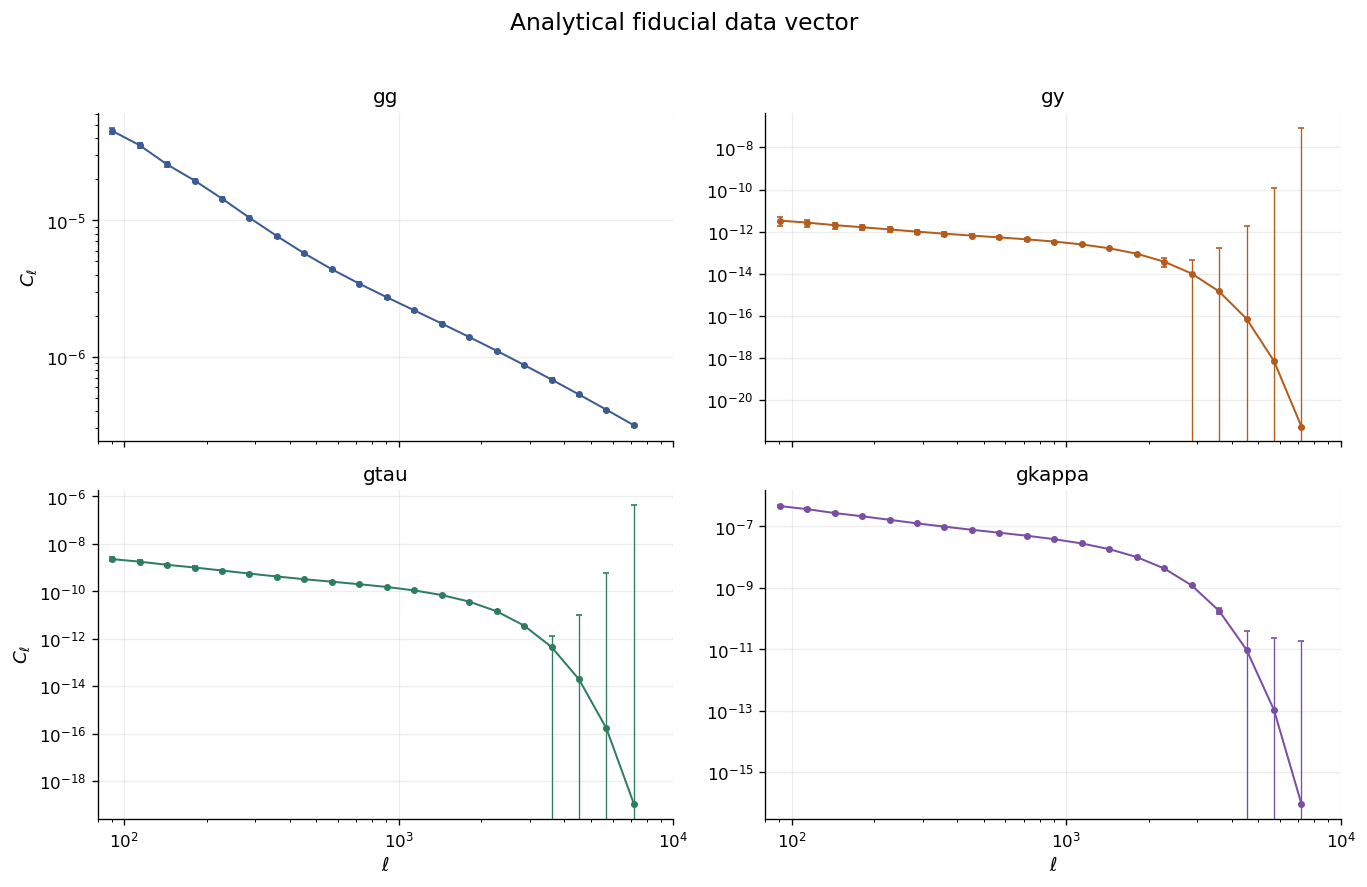

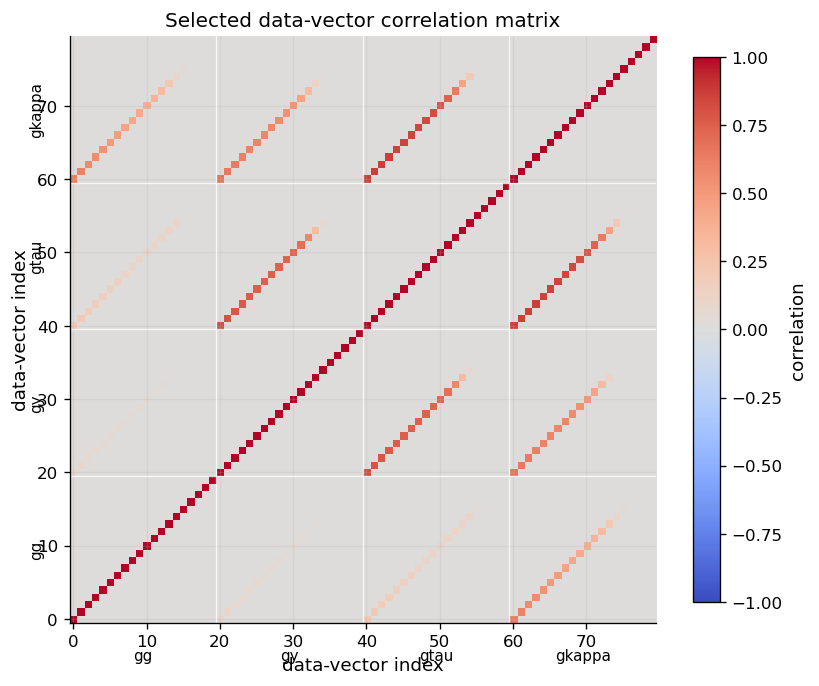

In [20]:
PROBE_COLORS = {
    "gg": "#3b5b92",
    "gy": "#b35c1e",
    "gtau": "#2f7d5f",
    "gkappa": "#7a4fa3",
}
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.2), sharex=True)
axes = axes.ravel()
nell = len(ell)
for ax, probe in zip(axes, PROBES):
    block = spectra_order.index(probe)
    full_idx = block * nell + selection.ell_indices
    local_idx = np.arange(PROBES.index(probe) * len(selection.ell_indices), (PROBES.index(probe) + 1) * len(selection.ell_indices))
    y = np.asarray(product["data_vector"], dtype=float)[full_idx]
    yerr = std[local_idx]
    color = PROBE_COLORS[probe]
    ax.errorbar(
        ell[selection.ell_indices],
        y,
        yerr=yerr,
        marker="o",
        ms=3.2,
        lw=1.2,
        elinewidth=0.8,
        capsize=2,
        color=color,
    )
    ax.set_title(probe)
    ax.set_xscale("log")
    # if np.all(y > 0) and np.all(y - yerr > 0):
    ax.set_yscale("log")
    ax.set_xlim(80, 10000)
    # else:
    #     linthresh = max(np.nanmedian(np.abs(y)) * 1.0e-2, 1.0e-20)
    #     ax.set_yscale("symlog", linthresh=linthresh)
for ax in axes[-2:]:
    ax.set_xlabel(r"$\ell$")
for ax in axes[::2]:
    ax.set_ylabel(r"$C_\ell$")
fig.suptitle("Analytical fiducial data vector", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()
plt.close(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(7.0, 6.0))
im = ax.imshow(corr, origin="lower", vmin=-1, vmax=1, cmap="coolwarm", interpolation="nearest")
ax.set_title("Selected data-vector correlation matrix")
ax.set_xlabel("data-vector index")
ax.set_ylabel("data-vector index")
fig.colorbar(im, ax=ax, label="correlation", shrink=0.85)
for boundary in range(len(selection.ell_indices), len(data_vector), len(selection.ell_indices)):
    ax.axhline(boundary - 0.5, color="white", lw=0.8, alpha=0.8)
    ax.axvline(boundary - 0.5, color="white", lw=0.8, alpha=0.8)
for i, probe in enumerate(PROBES):
    center = i * len(selection.ell_indices) + 0.5 * (len(selection.ell_indices) - 1)
    ax.text(center, -4.0, probe, ha="center", va="top", fontsize=9, clip_on=False)
    ax.text(-4.0, center, probe, ha="right", va="center", fontsize=9, rotation=90, clip_on=False)
fig.tight_layout()
plt.show()
plt.close(fig)

## Run Contract

A result must match the same data vector, covariance, selected indices, priors, fiducial point, probes, ell cuts, backend, and offset convention before it is used. The table below records every candidate directory checked.

In [21]:
def canonical_array(value: Any) -> np.ndarray:
    arr = np.asarray(value)
    if arr.dtype.kind in "fc":
        arr = np.asarray(arr, dtype=np.float64)
    elif arr.dtype.kind in "iu":
        arr = np.asarray(arr, dtype=np.int64)
    elif arr.dtype.kind == "b":
        arr = np.asarray(arr, dtype=np.bool_)
    else:
        arr = np.asarray(arr.astype(str))
    return np.ascontiguousarray(arr)


def array_digest(value: Any) -> str:
    arr = canonical_array(value)
    h = hashlib.sha256()
    h.update(str(arr.shape).encode("utf-8"))
    h.update(str(arr.dtype).encode("utf-8"))
    h.update(arr.tobytes())
    return h.hexdigest()


EXPECTED_ARRAYS = {
    "data_vector": data_vector,
    "cov": cov,
    "selection_indices": np.asarray(selection.indices, dtype=int),
    "selection_ell_indices": np.asarray(selection.ell_indices, dtype=int),
    "prior_min": PRIOR_MIN,
    "prior_max": PRIOR_MAX,
    "theta_fiducial": THETA_FIDUCIAL,
}
EXPECTED_HASHES = {key: array_digest(value) for key, value in EXPECTED_ARRAYS.items()}


def load_json(path: pathlib.Path) -> dict[str, Any]:
    if not path.exists():
        return {}
    return json.loads(path.read_text())


def metadata_from_npz(npz: np.lib.npyio.NpzFile) -> dict[str, Any]:
    if "metadata_json" not in npz.files:
        return {}
    raw = npz["metadata_json"]
    if hasattr(raw, "item"):
        raw = raw.item()
    if isinstance(raw, bytes):
        raw = raw.decode("utf-8")
    return json.loads(str(raw))


def paths_match(value: Any, expected: pathlib.Path) -> bool:
    if value is None:
        return False
    try:
        return pathlib.Path(str(value)).expanduser().resolve() == expected.resolve()
    except Exception:
        return False


def metadata_value(metadata: dict[str, Any], key: str) -> Any:
    if key in metadata:
        return metadata[key]
    selection_meta = metadata.get("selection")
    if isinstance(selection_meta, dict) and key in selection_meta:
        return selection_meta[key]
    return None


def check_parameter_specs(metadata: dict[str, Any], problems: list[str], *, required: bool) -> None:
    specs = metadata.get("parameter_specs")
    if specs is None:
        if required:
            problems.append("missing parameter_specs metadata")
        return
    names = [spec.get("name") for spec in specs]
    fid = np.array([spec.get("fiducial") for spec in specs], dtype=float)
    prior_min = np.array([spec.get("prior_min") for spec in specs], dtype=float)
    prior_max = np.array([spec.get("prior_max") for spec in specs], dtype=float)
    if tuple(names) != PARAM_NAMES:
        problems.append(f"parameter names mismatch: {names}")
    if array_digest(fid) != EXPECTED_HASHES["theta_fiducial"]:
        problems.append("parameter fiducials mismatch")
    if array_digest(prior_min) != EXPECTED_HASHES["prior_min"]:
        problems.append("parameter prior_min mismatch")
    if array_digest(prior_max) != EXPECTED_HASHES["prior_max"]:
        problems.append("parameter prior_max mismatch")


@dataclass(frozen=True)
class RunSpec:
    name: str
    kind: str
    fresh_dir: pathlib.Path
    candidate_dirs: tuple[pathlib.Path, ...]
    density_estimator: str | None = None
    parameter_transform: str | None = None
    schedule: tuple[int, ...] | None = None
    nsim: int | None = None
    likelihood: str | None = None

    @property
    def total_sims(self) -> int | None:
        if self.schedule is not None:
            return int(sum(self.schedule))
        return self.nsim


def sample_file_for(spec: RunSpec, output_dir: pathlib.Path) -> pathlib.Path:
    if spec.kind == "hmc":
        return output_dir / "hmc_samples.npz"
    if spec.kind == "sbi":
        return output_dir / "sbi_posterior_samples.npz"
    if spec.kind == "compressed":
        return output_dir / "compressed_likelihood_samples.npz"
    raise ValueError(spec.kind)


def diag_file_for(spec: RunSpec, output_dir: pathlib.Path) -> pathlib.Path:
    if spec.kind == "hmc":
        return output_dir / "hmc_diagnostics.json"
    if spec.kind == "sbi":
        return output_dir / "sbi_diagnostics.json"
    if spec.kind == "compressed":
        return output_dir / "compressed_likelihood_diagnostics.json"
    raise ValueError(spec.kind)


def validate_result(spec: RunSpec, output_dir: pathlib.Path) -> dict[str, Any]:
    output_dir = pathlib.Path(output_dir)
    sample_path = sample_file_for(spec, output_dir)
    diag_path = diag_file_for(spec, output_dir)
    problems: list[str] = []
    payload_hashes: dict[str, str] = {}

    if not sample_path.exists():
        problems.append(f"missing {sample_path.name}")
    if not diag_path.exists():
        problems.append(f"missing {diag_path.name}")
    if problems:
        return {
            "valid": False,
            "problems": "; ".join(problems),
            "sample_path": sample_path,
            "diag_path": diag_path,
            "payload_hashes": payload_hashes,
        }

    diagnostics = load_json(diag_path)
    with np.load(sample_path, allow_pickle=True) as npz:
        metadata = metadata_from_npz(npz)
        metadata.update(diagnostics)

        for key, expected_hash in EXPECTED_HASHES.items():
            if key not in npz.files:
                problems.append(f"missing array {key}")
                continue
            got_hash = array_digest(npz[key])
            payload_hashes[key] = got_hash
            if got_hash != expected_hash:
                problems.append(f"{key} hash mismatch")

        if not paths_match(metadata.get("fiducial_path"), FIDUCIAL_PATH):
            problems.append("fiducial_path mismatch or missing")
        if metadata.get("theory_backend") != THEORY_BACKEND:
            problems.append(f"theory_backend mismatch: {metadata.get('theory_backend')}")
        if bool(metadata.get("fiducial_offset_correction")) != FIDUCIAL_OFFSET:
            problems.append(f"fiducial_offset_correction mismatch: {metadata.get('fiducial_offset_correction')}")

        probes = tuple(metadata_value(metadata, "probes") or ())
        if probes != PROBES:
            problems.append(f"probes mismatch or missing: {probes}")
        if metadata_value(metadata, "ell_min") != ELL_MIN:
            problems.append(f"ell_min mismatch: {metadata_value(metadata, 'ell_min')}")
        if metadata_value(metadata, "ell_max") != ELL_MAX:
            problems.append(f"ell_max mismatch: {metadata_value(metadata, 'ell_max')}")

        check_parameter_specs(metadata, problems, required=(spec.kind != "compressed"))

        if spec.kind == "hmc":
            divergences = int(np.asarray(npz["extra_diverging"]).sum()) if "extra_diverging" in npz.files else -1
            if divergences != 0:
                problems.append(f"HMC divergences = {divergences}")
            max_rhat = diagnostics.get("max_rhat")
            min_ess = diagnostics.get("min_ess_bulk")
            if max_rhat is None or float(max_rhat) > HMC_RHAT_MAX:
                problems.append(f"HMC max_rhat too large or missing: {max_rhat}")
            if min_ess is None or float(min_ess) < HMC_ESS_MIN:
                problems.append(f"HMC min_ess_bulk too small or missing: {min_ess}")
            if int(metadata.get("num_warmup", -1)) != 6000:
                problems.append(f"HMC num_warmup mismatch: {metadata.get('num_warmup')}")
            if int(metadata.get("num_samples", -1)) != 6000:
                problems.append(f"HMC num_samples mismatch: {metadata.get('num_samples')}")
            if int(metadata.get("num_chains", -1)) != 4:
                problems.append(f"HMC num_chains mismatch: {metadata.get('num_chains')}")

        elif spec.kind == "sbi":
            if metadata.get("summary_compression") != SUMMARY_COMPRESSION:
                problems.append(f"summary_compression mismatch: {metadata.get('summary_compression')}")
            if metadata.get("density_estimator") != spec.density_estimator:
                problems.append(f"density_estimator mismatch: {metadata.get('density_estimator')}")
            if metadata.get("parameter_transform") != spec.parameter_transform:
                problems.append(f"parameter_transform mismatch: {metadata.get('parameter_transform')}")
            schedule = tuple(int(x) for x in metadata.get("simulations_per_round", []))
            if schedule != spec.schedule:
                problems.append(f"simulations_per_round mismatch: {schedule}")
            if int(metadata.get("posterior_samples", -1)) != SNPE_POSTERIOR_SAMPLES:
                problems.append(f"posterior_samples mismatch: {metadata.get('posterior_samples')}")

        elif spec.kind == "compressed":
            if diagnostics.get("likelihood") != spec.likelihood:
                problems.append(f"likelihood mismatch: {diagnostics.get('likelihood')}")
            if int(diagnostics.get("nsim", -1)) != int(spec.nsim):
                problems.append(f"nsim mismatch: {diagnostics.get('nsim')}")
            if bool(diagnostics.get("use_true_covariance")):
                problems.append("use_true_covariance must be false")

    return {
        "valid": len(problems) == 0,
        "problems": "; ".join(problems),
        "sample_path": sample_path,
        "diag_path": diag_path,
        "payload_hashes": payload_hashes,
    }

print("Expected array digests")
display_table([{"array": key, "sha256": value[:16] + "..."} for key, value in EXPECTED_HASHES.items()])

Expected array digests


,array,sha256
0,data_vector,a9e39ef2d4963b66...
1,cov,1f6e0a6d11c2471e...
2,selection_indices,c35bdca0025ff1a0...
3,selection_ell_indices,c650085af29de824...
4,prior_min,78d7a0836018b4fd...
5,prior_max,0310ba18b97c582f...
6,theta_fiducial,461016f0d5f836f7...


In [22]:
def schedule_tag(schedule: tuple[int, ...]) -> str:
    if len(set(schedule)) == 1:
        return f"{len(schedule)}x{schedule[0]}"
    return "_".join(str(x) for x in schedule)


hmc_existing = pathlib.Path(THEORY_SBI_DIR) / "joint_gg_gy_gtau_gkappa_linearized_hmc_strict"
hmc_fresh = LOWBUDGET_DIR / "hmc_strict"

RUN_SPECS: list[RunSpec] = [
    RunSpec(
        name="hmc_strict",
        kind="hmc",
        fresh_dir=hmc_fresh,
        candidate_dirs=(hmc_existing, hmc_fresh),
    )
]

snpe_schedules = [(256,), (256, 256), (256, 256, 256, 256)]
for density in ("nsf", "mdn"):
    for transform, basis in (("none", "raw"), ("fisher", "fisher")):
        for schedule in snpe_schedules:
            tag = schedule_tag(schedule)
            name = f"snpe_{density}_{basis}_{tag}"
            fresh_dir = LOWBUDGET_DIR / name
            RUN_SPECS.append(
                RunSpec(
                    name=name,
                    kind="sbi",
                    fresh_dir=fresh_dir,
                    candidate_dirs=(fresh_dir,),
                    density_estimator=density,
                    parameter_transform=transform,
                    schedule=schedule,
                )
            )

for nsim in (64, 128, 256):
    name = f"student_t_nsim{nsim}"
    fresh_dir = LOWBUDGET_DIR / name
    legacy = pathlib.Path(THEORY_SBI_DIR) / f"compressed_likelihood_student_t_nsim{nsim}"
    candidate_dirs = (fresh_dir, legacy) if legacy.exists() else (fresh_dir,)
    RUN_SPECS.append(
        RunSpec(
            name=name,
            kind="compressed",
            fresh_dir=fresh_dir,
            candidate_dirs=candidate_dirs,
            nsim=nsim,
            likelihood="student_t",
        )
    )

spec_rows = [
    {
        "name": spec.name,
        "kind": spec.kind,
        "estimator": spec.density_estimator,
        "basis": spec.parameter_transform,
        "schedule/nsim": spec.schedule if spec.schedule is not None else spec.nsim,
        "fresh_dir": str(spec.fresh_dir.relative_to(SBI_DIR)),
    }
    for spec in RUN_SPECS
]
display_table(spec_rows)

,name,kind,estimator,basis,schedule/nsim,fresh_dir
0,hmc_strict,hmc,None,None,None,outputs/theory_sbi/analytical_sbi_active_learn...
1,snpe_nsf_raw_1x256,sbi,nsf,none,"(256,)",outputs/theory_sbi/analytical_sbi_active_learn...
2,snpe_nsf_raw_2x256,sbi,nsf,none,"(256, 256)",outputs/theory_sbi/analytical_sbi_active_learn...
3,snpe_nsf_raw_4x256,sbi,nsf,none,"(256, 256, 256, 256)",outputs/theory_sbi/analytical_sbi_active_learn...
4,snpe_nsf_fisher_1x256,sbi,nsf,fisher,"(256,)",outputs/theory_sbi/analytical_sbi_active_learn...
5,snpe_nsf_fisher_2x256,sbi,nsf,fisher,"(256, 256)",outputs/theory_sbi/analytical_sbi_active_learn...
6,snpe_nsf_fisher_4x256,sbi,nsf,fisher,"(256, 256, 256, 256)",outputs/theory_sbi/analytical_sbi_active_learn...
7,snpe_mdn_raw_1x256,sbi,mdn,none,"(256,)",outputs/theory_sbi/analytical_sbi_active_learn...
8,snpe_mdn_raw_2x256,sbi,mdn,none,"(256, 256)",outputs/theory_sbi/analytical_sbi_active_learn...
9,snpe_mdn_raw_4x256,sbi,mdn,none,"(256, 256, 256, 256)",outputs/theory_sbi/analytical_sbi_active_learn...


In [23]:
def command_for(spec: RunSpec) -> list[str]:
    py = str(PYTHON_EXE)
    fid = str(FIDUCIAL_PATH)
    out = str(spec.fresh_dir)
    if spec.kind == "hmc":
        return [
            py,
            str(SBI_DIR / "run_hmc_theory_cls.py"),
            "--fiducial-path", fid,
            "--output-dir", out,
            "--probes", ",".join(PROBES),
            "--theory-backend", THEORY_BACKEND,
            "--num-warmup", "6000",
            "--num-samples", "6000",
            "--num-chains", "4",
            "--max-tree-depth", "12",
            "--target-accept-prob", "0.98",
            "--chain-method", "vectorized",
            "--seed", str(SEED),
        ]
    if spec.kind == "sbi":
        assert spec.schedule is not None
        assert spec.density_estimator is not None
        assert spec.parameter_transform is not None
        return [
            py,
            str(SBI_DIR / "run_sbi_theory_cls.py"),
            "--fiducial-path", fid,
            "--output-dir", out,
            "--probes", ",".join(PROBES),
            "--theory-backend", THEORY_BACKEND,
            "--summary-compression", SUMMARY_COMPRESSION,
            "--density-estimator-model", spec.density_estimator,
            "--parameter-transform", spec.parameter_transform,
            "--simulations-per-round", ",".join(str(x) for x in spec.schedule),
            "--posterior-samples", str(SNPE_POSTERIOR_SAMPLES),
            "--hidden-features", "64",
            "--num-transforms", "5",
            "--num-components", "5",
            "--num-bins", "10",
            "--training-batch-size", "128",
            "--max-num-epochs", "250",
            "--validation-fraction", "0.1",
            "--learning-rate", "5.0e-4",
            "--num-atoms", "10",
            "--device", "cpu",
            "--seed", str(SEED),
        ]
    if spec.kind == "compressed":
        assert spec.nsim is not None
        assert spec.likelihood is not None
        return [
            py,
            str(SBI_DIR / "run_compressed_likelihood_theory_cls.py"),
            "--fiducial-path", fid,
            "--output-dir", out,
            "--probes", ",".join(PROBES),
            "--theory-backend", THEORY_BACKEND,
            "--likelihood", spec.likelihood,
            "--nsim", str(spec.nsim),
            "--ngrid", str(COMPRESSED_NGRID),
            "--posterior-samples", str(COMPRESSED_POSTERIOR_SAMPLES),
            "--seed", str(SEED),
        ]
    raise ValueError(spec.kind)


def run_fresh(spec: RunSpec) -> tuple[bool, str, float]:
    cmd = command_for(spec)
    env = os.environ.copy()
    env.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
    if FORCE_CPU_RUNS:
        env["CUDA_VISIBLE_DEVICES"] = ""
        env["JAX_PLATFORMS"] = "cpu"
        env.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
    print("Running fresh command:")
    print(" ".join(cmd))
    t0 = time.time()
    proc = subprocess.run(cmd, cwd=str(SBI_DIR), env=env, text=True, capture_output=True)
    elapsed = time.time() - t0
    if proc.stdout:
        print(proc.stdout[-4000:])
    if proc.stderr:
        print(proc.stderr[-4000:])
    return proc.returncode == 0, f"returncode={proc.returncode}", elapsed


def resolve_runs(specs: list[RunSpec]) -> tuple[dict[str, dict[str, Any]], list[dict[str, Any]]]:
    accepted: dict[str, dict[str, Any]] = {}
    rows: list[dict[str, Any]] = []

    for spec in specs:
        chosen: pathlib.Path | None = None
        chosen_validation: dict[str, Any] | None = None

        if FORCE_RERUN and RUN_MISSING:
            ok, message, elapsed = run_fresh(spec)
            rows.append({
                "name": spec.name,
                "kind": spec.kind,
                "candidate": str(spec.fresh_dir.relative_to(SBI_DIR) if spec.fresh_dir.is_relative_to(SBI_DIR) else spec.fresh_dir),
                "status": "fresh_run_ok" if ok else "fresh_run_failed",
                "problems": message,
                "elapsed_sec": round(elapsed, 1),
            })

        for candidate in spec.candidate_dirs:
            validation = validate_result(spec, candidate)
            status = "accepted" if validation["valid"] and chosen is None else ("valid_not_used" if validation["valid"] else "rejected")
            rows.append({
                "name": spec.name,
                "kind": spec.kind,
                "candidate": str(candidate.relative_to(SBI_DIR) if candidate.is_relative_to(SBI_DIR) else candidate),
                "status": status,
                "problems": validation["problems"],
                "data_hash": validation["payload_hashes"].get("data_vector", "")[:12],
                "cov_hash": validation["payload_hashes"].get("cov", "")[:12],
                "elapsed_sec": "",
            })
            if validation["valid"] and chosen is None:
                chosen = candidate
                chosen_validation = validation

        if chosen is None and RUN_MISSING:
            ok, message, elapsed = run_fresh(spec)
            validation = validate_result(spec, spec.fresh_dir)
            rows.append({
                "name": spec.name,
                "kind": spec.kind,
                "candidate": str(spec.fresh_dir.relative_to(SBI_DIR) if spec.fresh_dir.is_relative_to(SBI_DIR) else spec.fresh_dir),
                "status": "accepted_after_run" if ok and validation["valid"] else "fresh_run_invalid",
                "problems": validation["problems"] or message,
                "data_hash": validation["payload_hashes"].get("data_vector", "")[:12],
                "cov_hash": validation["payload_hashes"].get("cov", "")[:12],
                "elapsed_sec": round(elapsed, 1),
            })
            if ok and validation["valid"]:
                chosen = spec.fresh_dir
                chosen_validation = validation

        if chosen is not None:
            accepted[spec.name] = {"spec": spec, "dir": pathlib.Path(chosen), "validation": chosen_validation}
        else:
            rows.append({
                "name": spec.name,
                "kind": spec.kind,
                "candidate": str(spec.fresh_dir.relative_to(SBI_DIR) if spec.fresh_dir.is_relative_to(SBI_DIR) else spec.fresh_dir),
                "status": "not_available",
                "problems": "Set RUN_MISSING=True to generate this run" if not RUN_MISSING else "fresh run not accepted",
                "data_hash": "",
                "cov_hash": "",
                "elapsed_sec": "",
            })

    return accepted, rows

accepted_runs, contract_rows = resolve_runs(RUN_SPECS)
display_table(
    contract_rows,
    columns=["name", "kind", "candidate", "status", "problems", "data_hash", "cov_hash", "elapsed_sec"],
)
print(f"Accepted runs: {len(accepted_runs)} / {len(RUN_SPECS)}")




,name,kind,candidate,status,problems,data_hash,cov_hash,elapsed_sec
0,hmc_strict,hmc,outputs/theory_sbi/joint_gg_gy_gtau_gkappa_lin...,accepted,,a9e39ef2d496,1f6e0a6d11c2,
1,hmc_strict,hmc,outputs/theory_sbi/analytical_sbi_active_learn...,rejected,missing hmc_samples.npz; missing hmc_diagnosti...,,,
2,snpe_nsf_raw_1x256,sbi,outputs/theory_sbi/analytical_sbi_active_learn...,accepted,,a9e39ef2d496,1f6e0a6d11c2,
3,snpe_nsf_raw_2x256,sbi,outputs/theory_sbi/analytical_sbi_active_learn...,accepted,,a9e39ef2d496,1f6e0a6d11c2,
4,snpe_nsf_raw_4x256,sbi,outputs/theory_sbi/analytical_sbi_active_learn...,accepted,,a9e39ef2d496,1f6e0a6d11c2,
5,snpe_nsf_fisher_1x256,sbi,outputs/theory_sbi/analytical_sbi_active_learn...,accepted,,a9e39ef2d496,1f6e0a6d11c2,
6,snpe_nsf_fisher_2x256,sbi,outputs/theory_sbi/analytical_sbi_active_learn...,accepted,,a9e39ef2d496,1f6e0a6d11c2,
7,snpe_nsf_fisher_4x256,sbi,outputs/theory_sbi/analytical_sbi_active_learn...,accepted,,a9e39ef2d496,1f6e0a6d11c2,
8,snpe_mdn_raw_1x256,sbi,outputs/theory_sbi/analytical_sbi_active_learn...,accepted,,a9e39ef2d496,1f6e0a6d11c2,
9,snpe_mdn_raw_2x256,sbi,outputs/theory_sbi/analytical_sbi_active_learn...,accepted,,a9e39ef2d496,1f6e0a6d11c2,


Accepted runs: 16 / 16


## HMC Benchmark

The strict HMC chain is the benchmark. The notebook only proceeds with posterior comparisons if a validated HMC run is available.

In [24]:
def load_samples_from_record(record: dict[str, Any]) -> np.ndarray:
    spec: RunSpec = record["spec"]
    output_dir = pathlib.Path(record["dir"])
    sample_path = sample_file_for(spec, output_dir)
    with np.load(sample_path, allow_pickle=True) as npz:
        if spec.kind == "hmc":
            return np.column_stack([np.asarray(npz[f"samples_{name}"], dtype=float) for name in PARAM_NAMES])
        return np.asarray(npz["samples"], dtype=float)


def pretty_label(record: dict[str, Any]) -> str:
    spec: RunSpec = record["spec"]
    if spec.kind == "hmc":
        return "HMC strict"
    if spec.kind == "compressed":
        return f"Student-t {spec.nsim} sims"
    basis = "raw" if spec.parameter_transform == "none" else "Fisher"
    return f"SNPE-{spec.density_estimator.upper()} {basis} {schedule_tag(spec.schedule)}"


if "hmc_strict" not in accepted_runs:
    raise RuntimeError("No validated strict HMC benchmark is available. Set RUN_MISSING=True and rerun.")

posterior_samples: dict[str, np.ndarray] = {
    name: load_samples_from_record(record) for name, record in accepted_runs.items()
}
hmc_samples = posterior_samples["hmc_strict"]
hmc_mean = hmc_samples.mean(axis=0)
hmc_cov = np.cov(hmc_samples.T, ddof=1)
hmc_std = np.sqrt(np.diag(hmc_cov))
hmc_inv_cov = np.linalg.pinv(hmc_cov)
hmc_eigvals, hmc_eigvecs = np.linalg.eigh(hmc_cov)
hmc_order = np.argsort(hmc_eigvals)[::-1]
hmc_eigvals = hmc_eigvals[hmc_order]
hmc_eigvecs = hmc_eigvecs[:, hmc_order]
hmc_dir_widths = np.sqrt(hmc_eigvals)

hmc_npz = np.load(sample_file_for(accepted_runs["hmc_strict"]["spec"], accepted_runs["hmc_strict"]["dir"]), allow_pickle=True)
jac = np.asarray(hmc_npz["theory_jacobian"], dtype=float)
chol = np.asarray(hmc_npz["chol"], dtype=float)
jac_white = np.linalg.solve(chol, jac)
fisher = 0.5 * (jac_white.T @ jac_white + (jac_white.T @ jac_white).T)
fisher_transform = np.linalg.cholesky(fisher)
fisher_inv = np.linalg.inv(fisher_transform)

hmc_diag = load_json(diag_file_for(accepted_runs["hmc_strict"]["spec"], accepted_runs["hmc_strict"]["dir"]))
hmc_rows = [
    {"quantity": "samples", "value": len(hmc_samples)},
    {"quantity": "mean theta_ej_0", "value": hmc_mean[0]},
    {"quantity": "mean nu_theta_ej_M", "value": hmc_mean[1]},
    {"quantity": "std theta_ej_0", "value": hmc_std[0]},
    {"quantity": "std nu_theta_ej_M", "value": hmc_std[1]},
    {"quantity": "corr", "value": np.corrcoef(hmc_samples.T)[0, 1]},
    {"quantity": "max_rhat", "value": hmc_diag.get("max_rhat")},
    {"quantity": "min_ess_bulk", "value": hmc_diag.get("min_ess_bulk")},
    {"quantity": "divergences", "value": int(np.asarray(hmc_npz["extra_diverging"]).sum())},
]
display_table(hmc_rows)
print("HMC covariance eigenvectors are columns ordered wide to narrow:")
print(hmc_eigvecs)
print("Fisher transform used for Fisher-coordinate views:")
print(fisher_transform)

,quantity,value
0,samples,24000.000000
1,mean theta_ej_0,1.989990
2,mean nu_theta_ej_M,-0.101491
3,std theta_ej_0,0.287700
4,std nu_theta_ej_M,0.043317
5,corr,0.997725
6,max_rhat,1.000000
7,min_ess_bulk,2468.000000
8,divergences,0.000000


HMC covariance eigenvectors are columns ordered wide to narrow:
[[-0.98890209  0.14856867]
 [-0.14856867 -0.98890209]]
Fisher transform used for Fisher-coordinate views:
[[  51.45495678    0.        ]
 [-341.08747616   21.9114396 ]]


In [25]:
%matplotlib inline

from getdist import MCSamples, plots, chains
from matplotlib.colors import to_hex

chains.print_load_details = False

GETDIST_SETTINGS = {
    "ignore_rows": 0,
    "smooth_scale_1D": 0.35,
    "smooth_scale_2D": 0.45,
    "boundary_correction_order": 1,
}

COORD_INFO = {
    "theta": {
        "names": ["thetaej0", "nuejM"],
        "labels": [r"\theta_{\rm ej,0}", r"\nu^M_{\theta_{\rm ej}}"],
    },
    "fisher": {
        "names": ["u0", "u1"],
        "labels": [r"u_0", r"u_1"],
    },
    "hmc_eig": {
        "names": ["wide", "narrow"],
        "labels": ["wide HMC direction", "narrow HMC direction"],
    },
}

METHOD_COLORS = {
    "hmc": "#8a8a8a",
    "student": "#2c7a3f",
    "nsf_raw": "#2f6db3",
    "nsf_fisher": "#1b9e9a",
    "mdn_raw": "#c7781e",
    "mdn_fisher": "#c23b3b",
}


def transform_samples(samples: np.ndarray, coord: str) -> np.ndarray:
    samples = np.asarray(samples, dtype=float)
    if coord == "theta":
        return samples
    if coord == "fisher":
        return (samples - THETA_FIDUCIAL[None, :]) @ fisher_transform
    if coord == "hmc_eig":
        return (samples - hmc_mean[None, :]) @ hmc_eigvecs
    raise ValueError(coord)


def coord_names(coord: str) -> list[str]:
    return list(COORD_INFO[coord]["names"])


def coord_labels(coord: str) -> list[str]:
    return list(COORD_INFO[coord]["labels"])


def fiducial_point(coord: str) -> np.ndarray:
    return transform_samples(THETA_FIDUCIAL[None, :], coord)[0]


def clean_samples(samples: np.ndarray, max_samples: int = 50_000) -> np.ndarray:
    samples = np.asarray(samples, dtype=float)
    finite = np.all(np.isfinite(samples), axis=1)
    samples = samples[finite]
    if len(samples) > max_samples:
        rng = np.random.default_rng(12345)
        keep = np.sort(rng.choice(len(samples), size=max_samples, replace=False))
        samples = samples[keep]
    return samples


def make_gd_samples(samples: np.ndarray, *, coord: str, label: str) -> MCSamples:
    pts = clean_samples(transform_samples(samples, coord))
    return MCSamples(
        samples=pts,
        names=coord_names(coord),
        labels=coord_labels(coord),
        label=label,
        settings=GETDIST_SETTINGS,
    )


def run_color(name: str) -> str:
    if name == "hmc_strict":
        return METHOD_COLORS["hmc"]
    if name.startswith("student_t"):
        return METHOD_COLORS["student"]
    if "nsf" in name and "fisher" in name:
        return METHOD_COLORS["nsf_fisher"]
    if "nsf" in name:
        return METHOD_COLORS["nsf_raw"]
    if "mdn" in name and "fisher" in name:
        return METHOD_COLORS["mdn_fisher"]
    if "mdn" in name:
        return METHOD_COLORS["mdn_raw"]
    return "#444444"


def run_line_style(name: str) -> str:
    if "1x256" in name or "nsim64" in name:
        return ":"
    if "2x256" in name or "nsim128" in name:
        return "--"
    return "-"


def pretty_label_short(name: str) -> str:
    if name not in accepted_runs:
        return name
    spec: RunSpec = accepted_runs[name]["spec"]
    if spec.kind == "hmc":
        return "HMC"
    if spec.kind == "compressed":
        return f"Student-t {spec.nsim}"
    basis = "raw" if spec.parameter_transform == "none" else "Fisher"
    return f"{spec.density_estimator.upper()} {basis} {schedule_tag(spec.schedule)}"


def get_gd(name: str, coord: str) -> MCSamples:
    return make_gd_samples(posterior_samples[name], coord=coord, label=pretty_label_short(name))


def available(names: list[str]) -> list[str]:
    missing = [name for name in names if name not in posterior_samples]
    if missing:
        print("Not yet available:", ", ".join(missing))
    return [name for name in names if name in posterior_samples]


def coord_limits(run_names: list[str], coord: str, pad_frac: float = 0.12) -> list[float] | None:
    pts = []
    for name in run_names:
        if name in posterior_samples:
            pts.append(transform_samples(posterior_samples[name], coord))
    if not pts:
        return None
    arr = np.vstack(pts)
    arr = arr[np.all(np.isfinite(arr), axis=1)]
    if len(arr) == 0:
        return None
    qlo, qhi = np.quantile(arr, [0.003, 0.997], axis=0)
    span = np.maximum(qhi - qlo, 1.0e-12)
    qlo = qlo - pad_frac * span
    qhi = qhi + pad_frac * span
    return [float(qlo[0]), float(qhi[0]), float(qlo[1]), float(qhi[1])]


def style_plotter(g):
    g.settings.axes_fontsize = 11
    g.settings.lab_fontsize = 13
    g.settings.legend_fontsize = 9
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.35
    g.settings.linewidth_contour = 1.5
    return g


def add_fiducial_marker(ax, coord: str):
    fid = fiducial_point(coord)
    ax.scatter(fid[0], fid[1], marker="*", s=95, color="#f4c430", edgecolor="black", linewidth=0.7, zorder=5)


def plot_hmc_triangle(coord: str = "theta"):
    if "hmc_strict" not in posterior_samples:
        print("No validated HMC run available.")
        return
    g = style_plotter(plots.get_subplot_plotter(width_inch=5.6))
    params = coord_names(coord)
    fid = fiducial_point(coord)
    markers = {params[0]: fid[0], params[1]: fid[1]}
    g.triangle_plot(
        [get_gd("hmc_strict", coord)],
        params=params,
        filled=True,
        contour_colors=[METHOD_COLORS["hmc"]],
        legend_labels=["HMC benchmark"],
        markers=markers,
        marker_args={"color": "#333333", "ls": ":", "lw": 1.0},
    )
    g.fig.suptitle(f"Strict HMC benchmark ({coord} coordinates)", y=1.02, fontsize=13)
    plt.show()
    plt.close(g.fig)


def plot_getdist_overlay(run_names: list[str], *, coord: str = "theta", title: str, legend_loc: str = "upper right"):
    run_names = available(run_names)
    if "hmc_strict" not in run_names and "hmc_strict" in posterior_samples:
        run_names = ["hmc_strict"] + run_names
    non_hmc = [name for name in run_names if name != "hmc_strict"]
    if not non_hmc:
        print(f"No non-HMC samples available for: {title}")
        return

    params = coord_names(coord)
    lims = coord_limits(run_names, coord)
    g = style_plotter(plots.get_single_plotter(width_inch=6.2))

    # Filled gray HMC reference. SBI contours are overlaid as unfilled colored lines.
    g.plot_2d(
        [get_gd("hmc_strict", coord)],
        params[0],
        params[1],
        filled=True,
        colors=[METHOD_COLORS["hmc"]],
        alphas=[0.28],
        lws=[1.0],
        lims=lims,
    )
    ax = plt.gca()
    labels = ["HMC benchmark"]
    for name in non_hmc:
        g.plot_2d(
            [get_gd(name, coord)],
            params[0],
            params[1],
            filled=False,
            colors=[run_color(name)],
            lws=[2.0],
            ls=[run_line_style(name)],
            lims=lims,
            ax=ax,
        )
        labels.append(pretty_label_short(name))
    add_fiducial_marker(ax, coord)
    ax.set_title(title, fontsize=12, pad=8)
    ax.grid(alpha=0.18)
    g.add_legend(labels, legend_loc=legend_loc, ax=ax, fontsize=8, frameon=False)
    plt.show()

## Clear Posterior Comparisons

The contour plots below use GetDist. In every comparison the strict HMC benchmark is the filled gray contour and the SBI approximation is shown as an unfilled colored contour. Separate panels are used for each question: compressed-likelihood budget, NSF active-learning budget, MDN active-learning budget, and the final cross-method comparison.

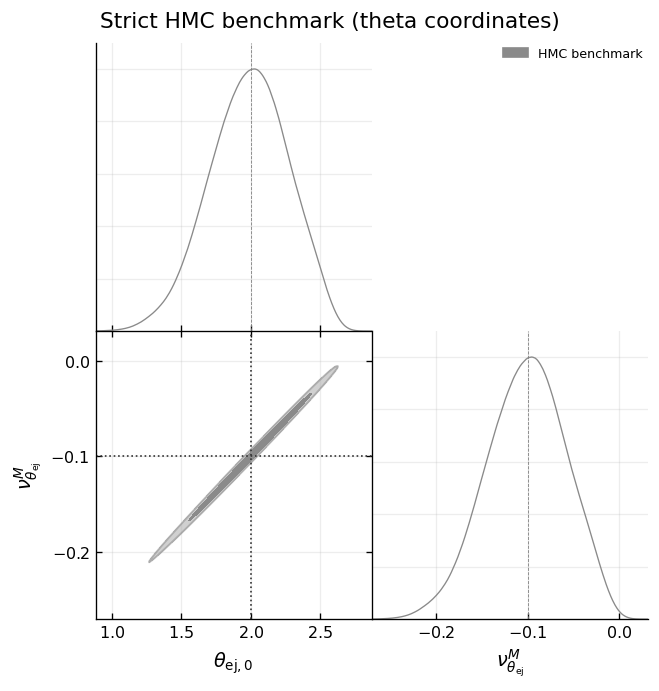

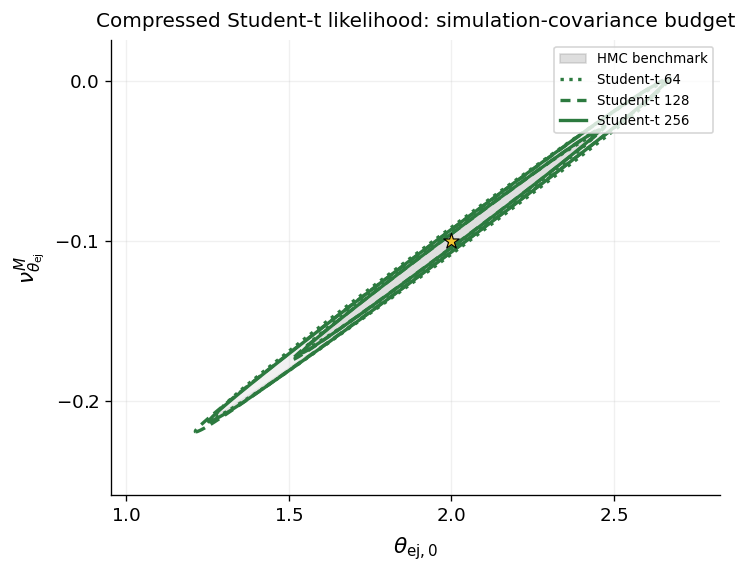

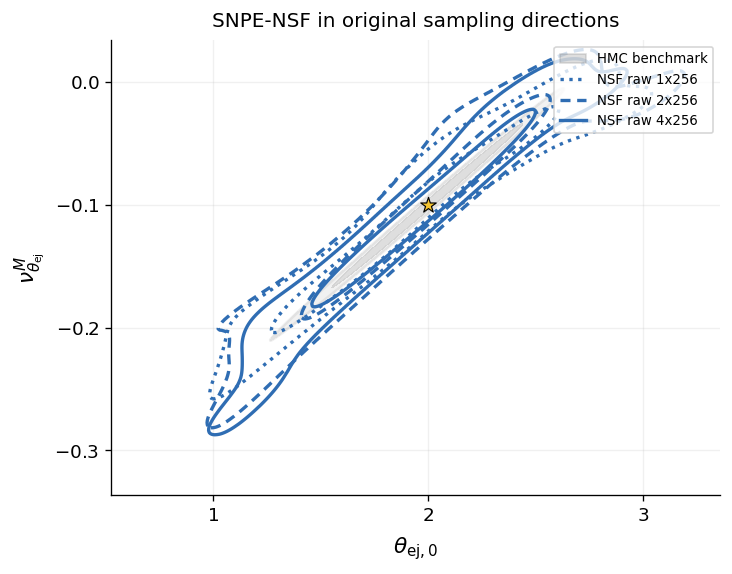

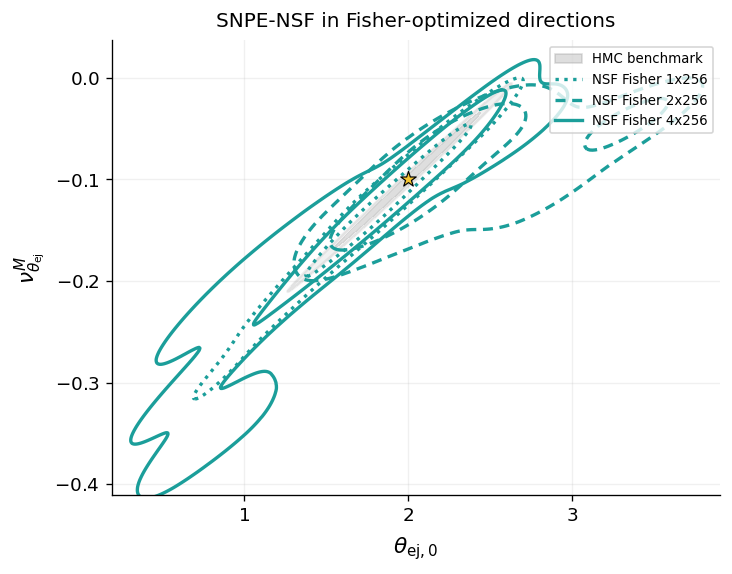

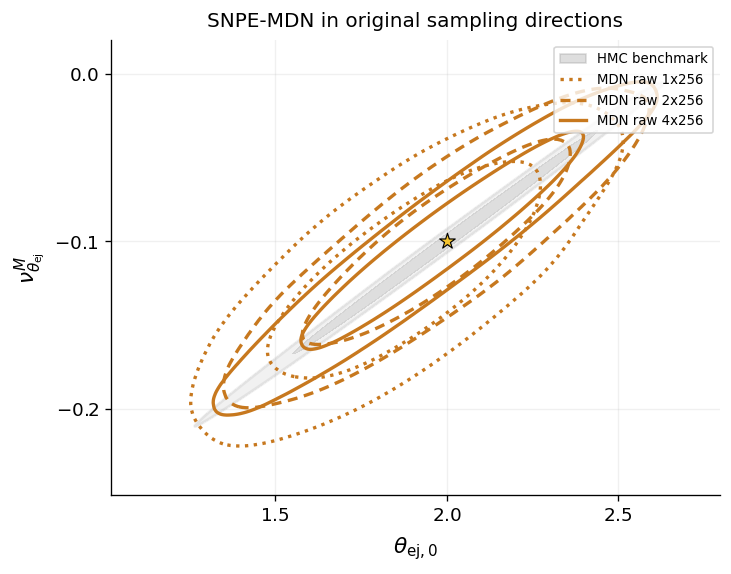

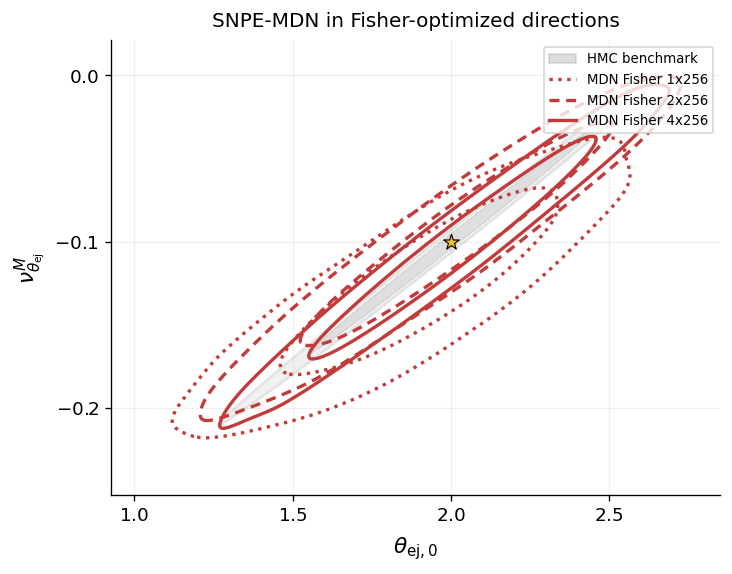

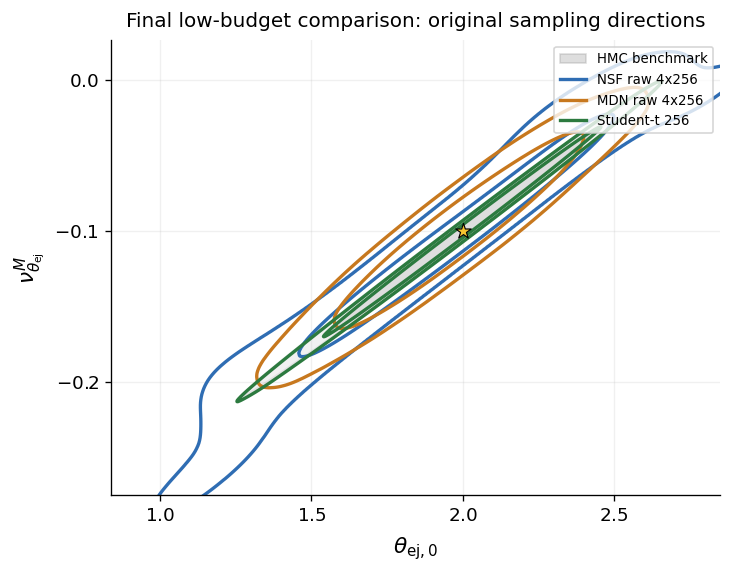

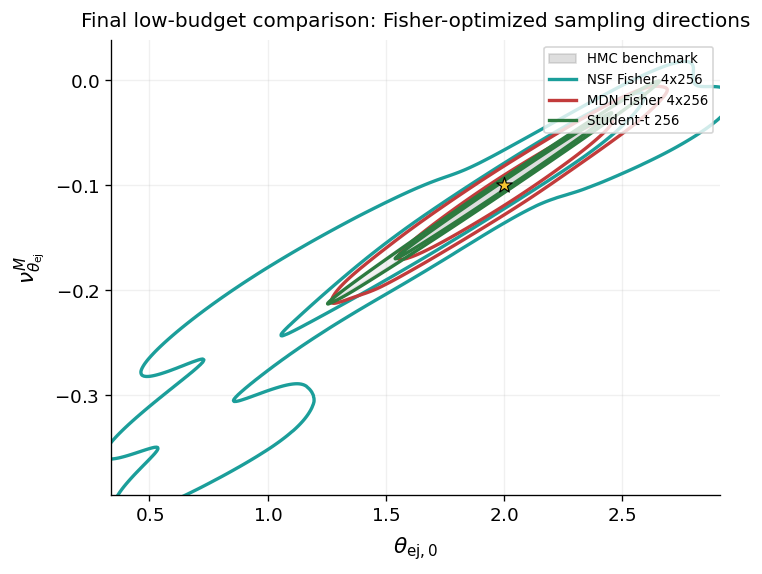

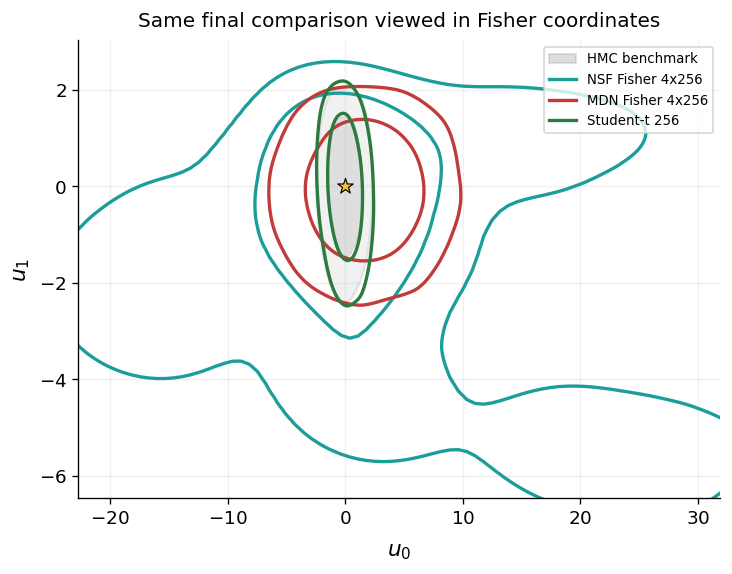

In [28]:
%matplotlib inline

plot_hmc_triangle(coord="theta")

plot_getdist_overlay(
    ["hmc_strict", "student_t_nsim64", "student_t_nsim128", "student_t_nsim256"],
    coord="theta",
    title="Compressed Student-t likelihood: simulation-covariance budget",
)

snpe_story_groups = [
    (["hmc_strict", "snpe_nsf_raw_1x256", "snpe_nsf_raw_2x256", "snpe_nsf_raw_4x256"], "SNPE-NSF in original sampling directions"),
    (["hmc_strict", "snpe_nsf_fisher_1x256", "snpe_nsf_fisher_2x256", "snpe_nsf_fisher_4x256"], "SNPE-NSF in Fisher-optimized directions"),
    (["hmc_strict", "snpe_mdn_raw_1x256", "snpe_mdn_raw_2x256", "snpe_mdn_raw_4x256"], "SNPE-MDN in original sampling directions"),
    (["hmc_strict", "snpe_mdn_fisher_1x256", "snpe_mdn_fisher_2x256", "snpe_mdn_fisher_4x256"], "SNPE-MDN in Fisher-optimized directions"),
]
for names, title in snpe_story_groups:
    plot_getdist_overlay(names, coord="theta", title=title)

plot_getdist_overlay(
    ["hmc_strict", "snpe_nsf_raw_4x256", "snpe_mdn_raw_4x256", "student_t_nsim256"],
    coord="theta",
    title="Final low-budget comparison: original sampling directions",
)
plot_getdist_overlay(
    ["hmc_strict", "snpe_nsf_fisher_4x256", "snpe_mdn_fisher_4x256", "student_t_nsim256"],
    coord="theta",
    title="Final low-budget comparison: Fisher-optimized sampling directions",
)

plot_getdist_overlay(
    ["hmc_strict", "snpe_nsf_fisher_4x256", "snpe_mdn_fisher_4x256", "student_t_nsim256"],
    coord="fisher",
    title="Same final comparison viewed in Fisher coordinates",
)

## Posterior Metrics Against HMC

The scalar metrics below track agreement with the strict HMC posterior as the simulation budget increases.

In [29]:
%matplotlib inline
def posterior_metrics(samples: np.ndarray) -> dict[str, float]:
    samples = np.asarray(samples, dtype=float)
    mean = samples.mean(axis=0)
    cov_i = np.cov(samples.T, ddof=1)
    std_i = np.sqrt(np.diag(cov_i))
    delta = mean - hmc_mean
    eig_cov = hmc_eigvecs.T @ cov_i @ hmc_eigvecs
    eig_widths = np.sqrt(np.clip(np.diag(eig_cov), 0.0, np.inf))
    return {
        "mean_shift_hmc_sigma": float(np.sqrt(delta @ hmc_inv_cov @ delta)),
        "theta_width_ratio": float(std_i[0] / hmc_std[0]),
        "nu_width_ratio": float(std_i[1] / hmc_std[1]),
        "area_ratio": float(np.sqrt(max(np.linalg.det(cov_i), 0.0) / max(np.linalg.det(hmc_cov), 1.0e-300))),
        "wide_dir_width_ratio": float(eig_widths[0] / hmc_dir_widths[0]),
        "narrow_dir_width_ratio": float(eig_widths[1] / hmc_dir_widths[1]),
    }

metric_rows = []
for name, samples in posterior_samples.items():
    record = accepted_runs[name]
    spec: RunSpec = record["spec"]
    row = {
        "name": name,
        "label": pretty_label(record),
        "kind": spec.kind,
        "estimator": spec.density_estimator or spec.likelihood or "hmc",
        "basis": "raw" if spec.parameter_transform == "none" else (spec.parameter_transform or "theta"),
        "total_sims": 0 if spec.kind == "hmc" else spec.total_sims,
        "source": str(pathlib.Path(record["dir"]).relative_to(SBI_DIR) if pathlib.Path(record["dir"]).is_relative_to(SBI_DIR) else record["dir"]),
    }
    row.update(posterior_metrics(samples))
    metric_rows.append(row)

metric_rows = sorted(metric_rows, key=lambda r: (r["kind"], str(r["estimator"]), str(r["basis"]), int(r["total_sims"] or 0)))
display_table(metric_rows)

,name,label,kind,estimator,basis,total_sims,source,mean_shift_hmc_sigma,theta_width_ratio,nu_width_ratio,area_ratio,wide_dir_width_ratio,narrow_dir_width_ratio
0,student_t_nsim64,Student-t 64 sims,compressed,student_t,theta,64,outputs/theory_sbi/analytical_sbi_active_learn...,0.026719,1.004027,1.003126,1.169813,1.003990,1.165425
1,student_t_nsim128,Student-t 128 sims,compressed,student_t,theta,128,outputs/theory_sbi/compressed_likelihood_stude...,0.030326,1.078274,1.085839,1.054682,1.078451,0.985124
2,student_t_nsim256,Student-t 256 sims,compressed,student_t,theta,256,outputs/theory_sbi/compressed_likelihood_stude...,0.016982,1.031239,1.040677,1.036760,1.031451,1.015120
3,hmc_strict,HMC strict,hmc,hmc,theta,0,outputs/theory_sbi/joint_gg_gy_gtau_gkappa_lin...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,snpe_mdn_fisher_1x256,SNPE-MDN Fisher 1x256,sbi,mdn,fisher,256,outputs/theory_sbi/analytical_sbi_active_learn...,3.631838,1.013088,0.850380,6.453602,1.007008,7.579671
5,snpe_mdn_fisher_2x256,SNPE-MDN Fisher 2x256,sbi,mdn,fisher,512,outputs/theory_sbi/analytical_sbi_active_learn...,0.621476,1.100139,1.009483,4.972247,1.097166,4.945465
6,snpe_mdn_fisher_4x256,SNPE-MDN Fisher 4x256,sbi,mdn,fisher,1024,outputs/theory_sbi/analytical_sbi_active_learn...,1.683194,1.031396,1.006965,3.410245,1.030366,3.379654
7,snpe_mdn_raw_1x256,SNPE-MDN raw 1x256,sbi,mdn,raw,256,outputs/theory_sbi/analytical_sbi_active_learn...,0.393549,0.904399,0.977268,8.392984,0.901151,9.549041
8,snpe_mdn_raw_2x256,SNPE-MDN raw 2x256,sbi,mdn,raw,512,outputs/theory_sbi/analytical_sbi_active_learn...,0.717391,0.886810,0.919462,6.123915,0.884835,7.039086
9,snpe_mdn_raw_4x256,SNPE-MDN raw 4x256,sbi,mdn,raw,1024,outputs/theory_sbi/analytical_sbi_active_learn...,0.928244,0.942716,0.974097,4.320721,0.942369,4.590095


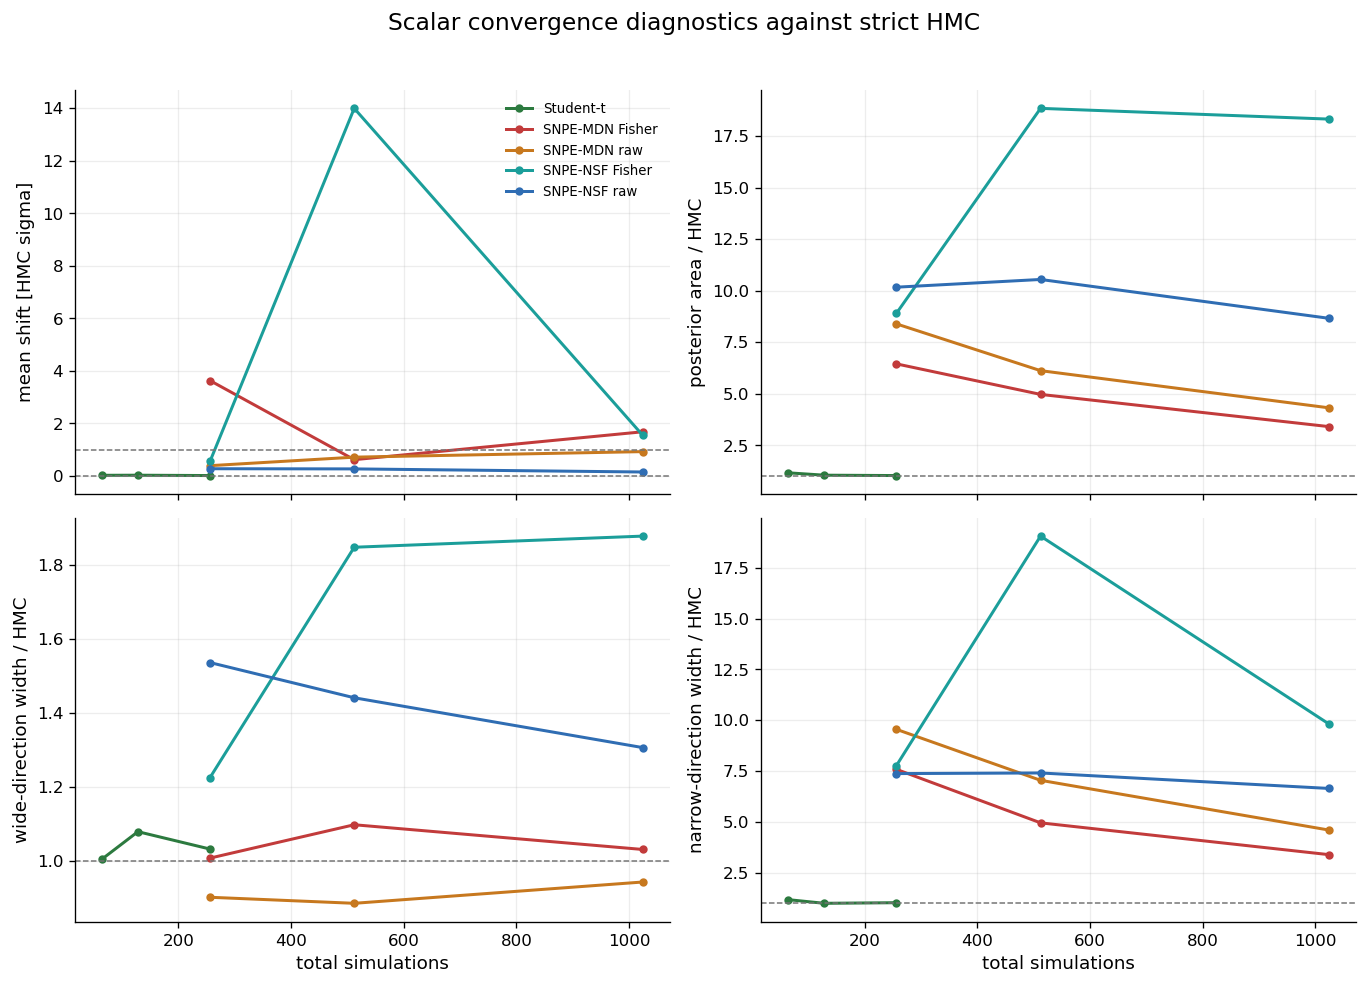

In [30]:
def plot_metric_grid(rows: list[dict[str, Any]]):
    plot_rows = [r for r in rows if r["kind"] != "hmc"]
    if not plot_rows:
        print("No non-HMC validated runs are available yet.")
        return
    metrics = [
        ("mean_shift_hmc_sigma", "mean shift [HMC sigma]"),
        ("area_ratio", "posterior area / HMC"),
        ("wide_dir_width_ratio", "wide-direction width / HMC"),
        ("narrow_dir_width_ratio", "narrow-direction width / HMC"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0), sharex=True)
    axes = axes.ravel()
    groups: dict[str, list[dict[str, Any]]] = {}
    for row in plot_rows:
        group = row["label"].replace(" 1x256", "").replace(" 2x256", "").replace(" 4x256", "")
        group = re.sub(r"Student-t \d+ sims", "Student-t", group)
        groups.setdefault(group, []).append(row)
    for ax, (metric, ylabel) in zip(axes, metrics):
        for group, group_rows in groups.items():
            group_rows = sorted(group_rows, key=lambda r: int(r["total_sims"] or 0))
            x = [int(r["total_sims"] or 0) for r in group_rows]
            y = [float(r[metric]) for r in group_rows]
            color = "#2c7a3f"
            if "NSF raw" in group:
                color = METHOD_COLORS["nsf_raw"]
            elif "NSF Fisher" in group:
                color = METHOD_COLORS["nsf_fisher"]
            elif "MDN raw" in group:
                color = METHOD_COLORS["mdn_raw"]
            elif "MDN Fisher" in group:
                color = METHOD_COLORS["mdn_fisher"]
            ax.plot(x, y, marker="o", lw=1.8, ms=4, label=group, color=color)
        ax.axhline(1.0, color="0.45", lw=0.9, ls="--")
        if metric == "mean_shift_hmc_sigma":
            ax.axhline(0.0, color="0.45", lw=0.9, ls="--")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.22)
    for ax in axes[-2:]:
        ax.set_xlabel("total simulations")
    axes[0].legend(fontsize=8, frameon=False)
    fig.suptitle("Scalar convergence diagnostics against strict HMC", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

plot_metric_grid(metric_rows)

## Active-Learning Round Diagnostics

The per-round plots are also made with GetDist. Each figure focuses on one run: HMC is the filled gray reference, and the SNPE posterior after each active-learning round is overlaid from light to dark. This avoids mixing NSF/MDN, raw/Fisher, and round number in one crowded panel.

In [31]:
def round_number(path: pathlib.Path) -> int:
    match = re.search(r"round(\d+)", path.name)
    return int(match.group(1)) if match else -1


def inference_to_theta_for_record(record: dict[str, Any], samples_inference: np.ndarray) -> np.ndarray:
    spec: RunSpec = record["spec"]
    output_dir = pathlib.Path(record["dir"])
    samples_inference = np.asarray(samples_inference, dtype=float)
    if spec.parameter_transform == "fisher":
        inv = np.load(output_dir / "sbi_parameter_transform_inverse.npy")
        return THETA_FIDUCIAL[None, :] + samples_inference @ inv
    return samples_inference


def sample_sbi_rounds(record: dict[str, Any], nsamples: int = ROUND_POSTERIOR_SAMPLES) -> dict[int, np.ndarray]:
    spec: RunSpec = record["spec"]
    if spec.kind != "sbi":
        return {}
    output_dir = pathlib.Path(record["dir"])
    pkl_paths = sorted(output_dir.glob("sbi_posterior_round*.pkl"), key=round_number)
    if not pkl_paths:
        return {}

    # Importing the module makes the custom FisherWhitenedBoxUniform class available for unpickling.
    import run_sbi_theory_cls  # noqa: F401
    import torch

    torch.manual_seed(SEED)
    out: dict[int, np.ndarray] = {}
    for path in pkl_paths:
        with path.open("rb") as handle:
            posterior = pickle.load(handle)
        draw = posterior.sample((nsamples,), show_progress_bars=False)
        draw_np = draw.detach().cpu().numpy()
        theta = inference_to_theta_for_record(record, draw_np)
        inside = np.all((theta >= PRIOR_MIN[None, :]) & (theta <= PRIOR_MAX[None, :]), axis=1)
        out[round_number(path)] = theta[inside]
    return out

round_samples_by_run: dict[str, dict[int, np.ndarray]] = {}
round_metric_rows: list[dict[str, Any]] = []
for name, record in accepted_runs.items():
    if record["spec"].kind != "sbi":
        continue
    rounds = sample_sbi_rounds(record)
    if not rounds:
        continue
    round_samples_by_run[name] = rounds
    schedule = record["spec"].schedule or ()
    cumulative = np.cumsum(schedule)
    for iround, samples in rounds.items():
        row = {
            "name": name,
            "label": pretty_label(record),
            "round": iround,
            "total_sims": int(cumulative[min(iround, len(cumulative) - 1)]),
            "nsamples": len(samples),
        }
        row.update(posterior_metrics(samples))
        round_metric_rows.append(row)

if round_metric_rows:
    display_table(round_metric_rows)
else:
    print("No accepted SNPE round posteriors are available yet. Set RUN_MISSING=True to generate them.")

,name,label,round,total_sims,nsamples,mean_shift_hmc_sigma,theta_width_ratio,nu_width_ratio,area_ratio,wide_dir_width_ratio,narrow_dir_width_ratio
0,snpe_nsf_raw_1x256,SNPE-NSF raw 1x256,0,256,4000,0.267942,1.555800,1.390989,10.590068,1.550542,7.676743
1,snpe_nsf_raw_2x256,SNPE-NSF raw 2x256,0,256,4000,0.267942,1.555800,1.390989,10.590068,1.550542,7.676743
2,snpe_nsf_raw_2x256,SNPE-NSF raw 2x256,1,512,4000,0.093669,1.444681,1.498595,12.385194,1.443437,8.617328
3,snpe_nsf_raw_4x256,SNPE-NSF raw 4x256,0,256,4000,0.267942,1.555800,1.390989,10.590068,1.550542,7.676743
4,snpe_nsf_raw_4x256,SNPE-NSF raw 4x256,1,512,4000,0.093669,1.444681,1.498595,12.385194,1.443437,8.617328
5,snpe_nsf_raw_4x256,SNPE-NSF raw 4x256,2,768,4000,0.493732,1.317396,1.356554,7.629395,1.317085,5.795754
6,snpe_nsf_raw_4x256,SNPE-NSF raw 4x256,3,1024,4000,0.143331,1.278685,1.398982,8.971458,1.279629,7.042055
7,snpe_nsf_fisher_1x256,SNPE-NSF Fisher 1x256,0,256,3891,0.550336,1.200264,1.145831,7.834668,1.197215,6.848450
8,snpe_nsf_fisher_2x256,SNPE-NSF Fisher 2x256,0,256,3891,0.550336,1.200264,1.145831,7.834668,1.197215,6.848450
9,snpe_nsf_fisher_2x256,SNPE-NSF Fisher 2x256,1,512,3885,14.139643,1.851289,1.009227,18.429801,1.827161,19.031607


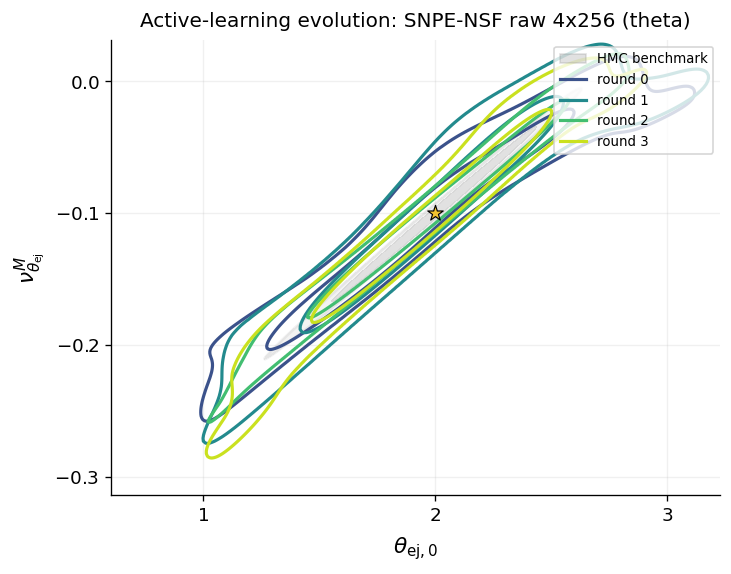

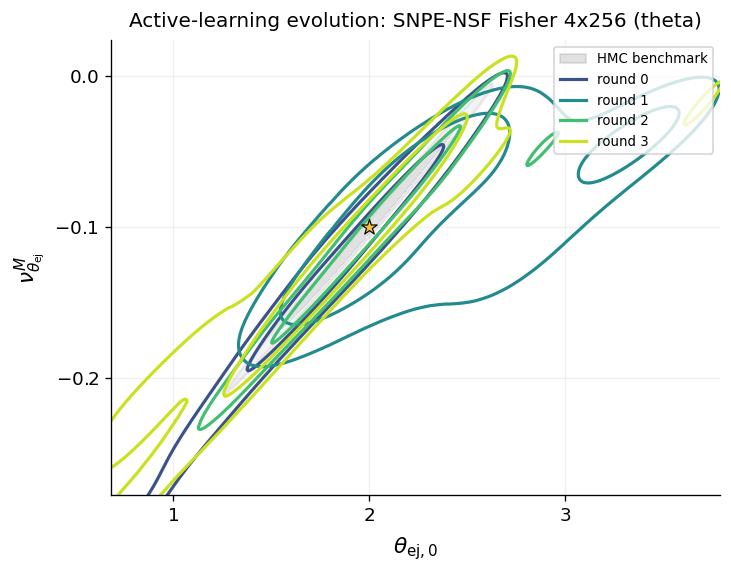

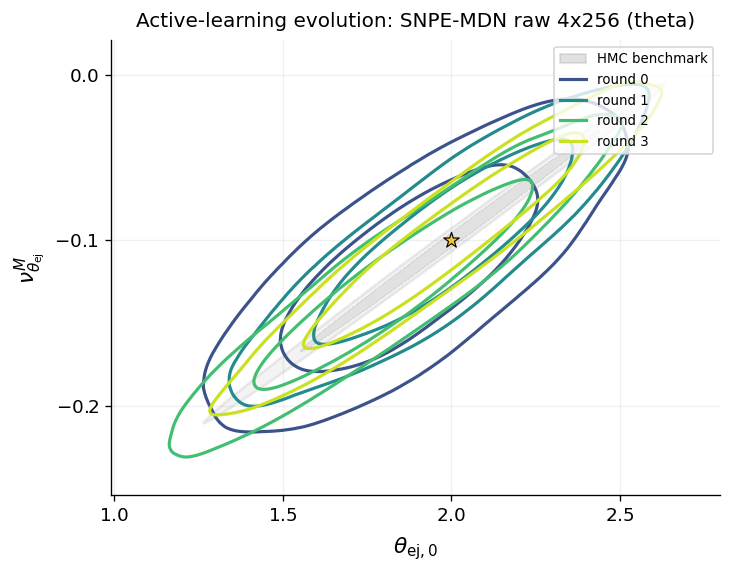

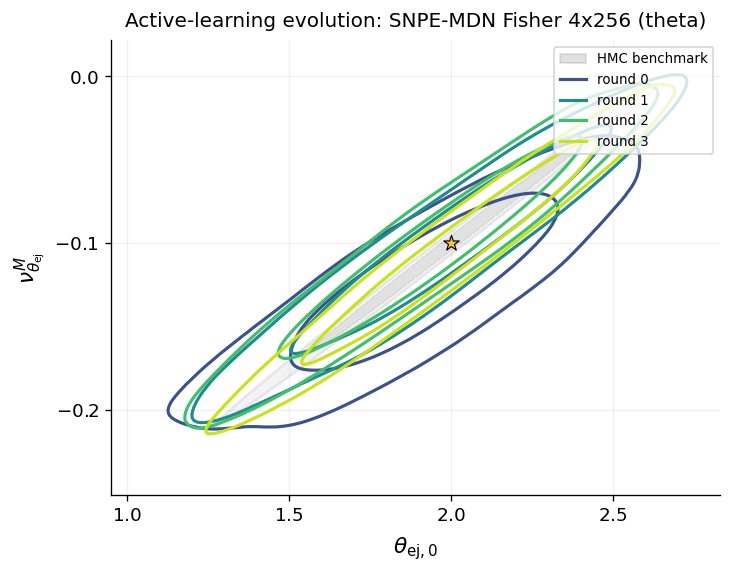

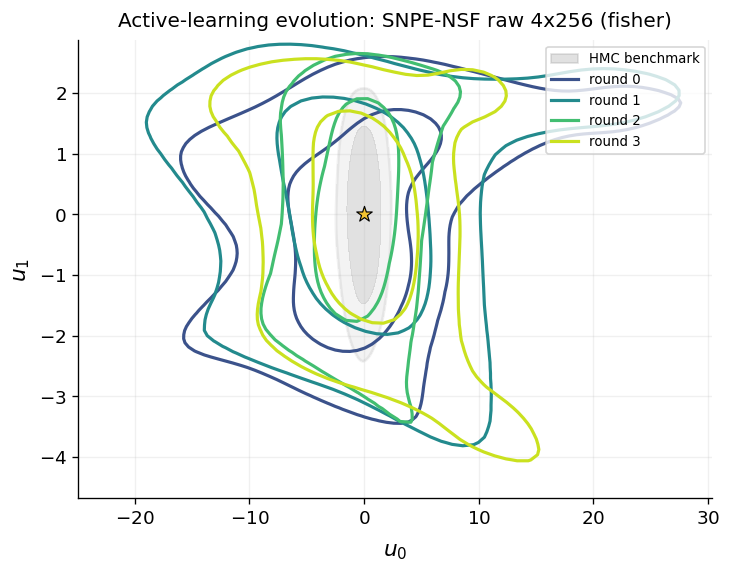

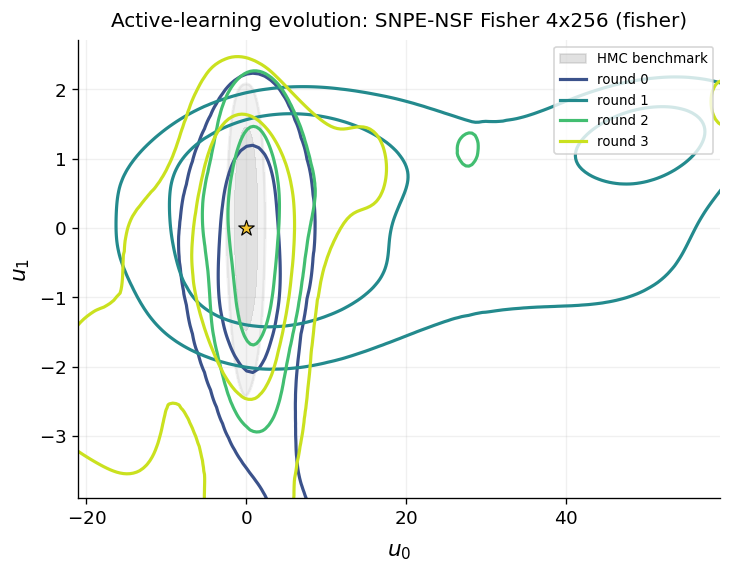

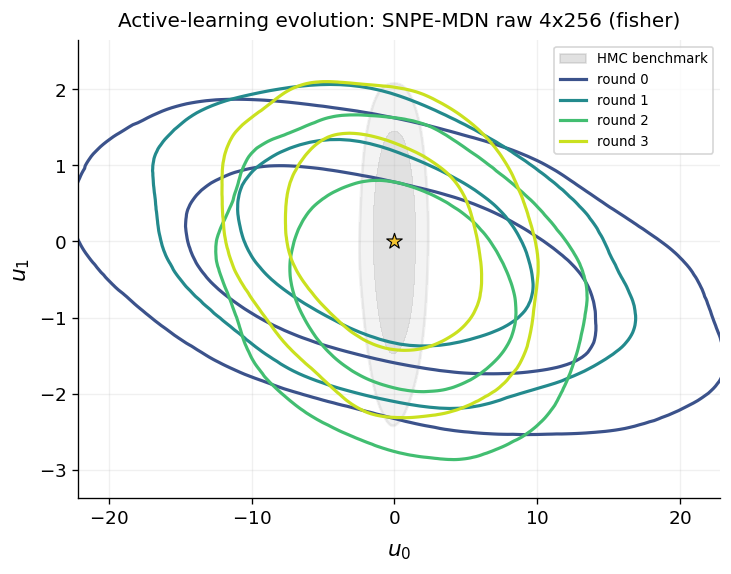

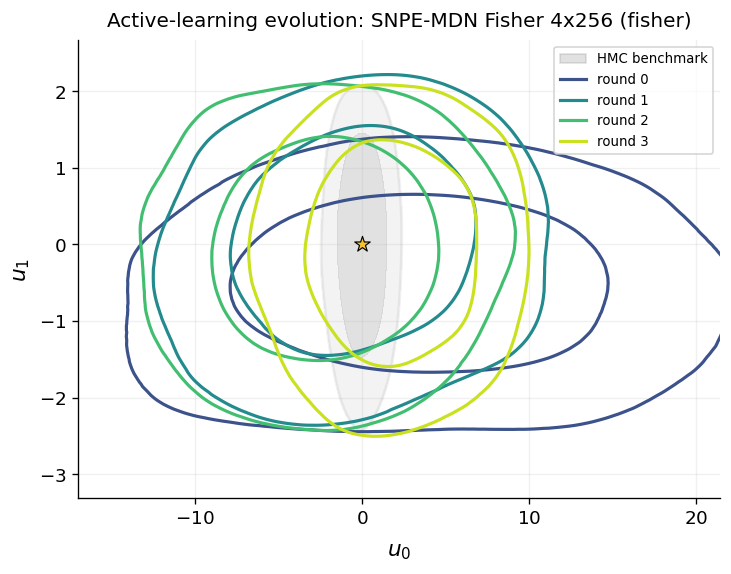

In [32]:
def plot_round_story(run_name: str, coord: str = "theta"):
    if run_name not in round_samples_by_run:
        print(f"No round samples available for {run_name}.")
        return
    rounds = round_samples_by_run[run_name]
    if not rounds:
        print(f"No round samples available for {run_name}.")
        return

    params = coord_names(coord)
    all_for_limits = {"hmc_strict": hmc_samples}
    for iround, samples in rounds.items():
        all_for_limits[f"round{iround}"] = samples
    pts = np.vstack([transform_samples(samples, coord) for samples in all_for_limits.values()])
    qlo, qhi = np.quantile(pts[np.all(np.isfinite(pts), axis=1)], [0.003, 0.997], axis=0)
    span = np.maximum(qhi - qlo, 1.0e-12)
    lims = [float(qlo[0] - 0.12 * span[0]), float(qhi[0] + 0.12 * span[0]), float(qlo[1] - 0.12 * span[1]), float(qhi[1] + 0.12 * span[1])]

    g = style_plotter(plots.get_single_plotter(width_inch=6.2))
    g.plot_2d(
        [get_gd("hmc_strict", coord)],
        params[0],
        params[1],
        filled=True,
        colors=[METHOD_COLORS["hmc"]],
        alphas=[0.25],
        lws=[1.0],
        lims=lims,
    )
    ax = plt.gca()
    labels = ["HMC benchmark"]
    colors = [to_hex(color) for color in plt.cm.viridis(np.linspace(0.25, 0.92, len(rounds)))]
    for color, (iround, samples) in zip(colors, sorted(rounds.items())):
        root = make_gd_samples(samples, coord=coord, label=f"round {iround}")
        g.plot_2d(
            [root],
            params[0],
            params[1],
            filled=False,
            colors=[color],
            lws=[1.9],
            ls=["-"],
            lims=lims,
            ax=ax,
        )
        labels.append(f"round {iround}")
    add_fiducial_marker(ax, coord)
    ax.set_title(f"Active-learning evolution: {pretty_label(accepted_runs[run_name])} ({coord})", fontsize=12, pad=8)
    ax.grid(alpha=0.18)
    g.add_legend(labels, legend_loc="upper right", ax=ax, fontsize=8, frameon=False)
    plt.show()
    plt.close(g.fig)

round_panel_names = [
    "snpe_nsf_raw_4x256",
    "snpe_nsf_fisher_4x256",
    "snpe_mdn_raw_4x256",
    "snpe_mdn_fisher_4x256",
]
for name in round_panel_names:
    plot_round_story(name, coord="theta")
for name in round_panel_names:
    plot_round_story(name, coord="fisher")

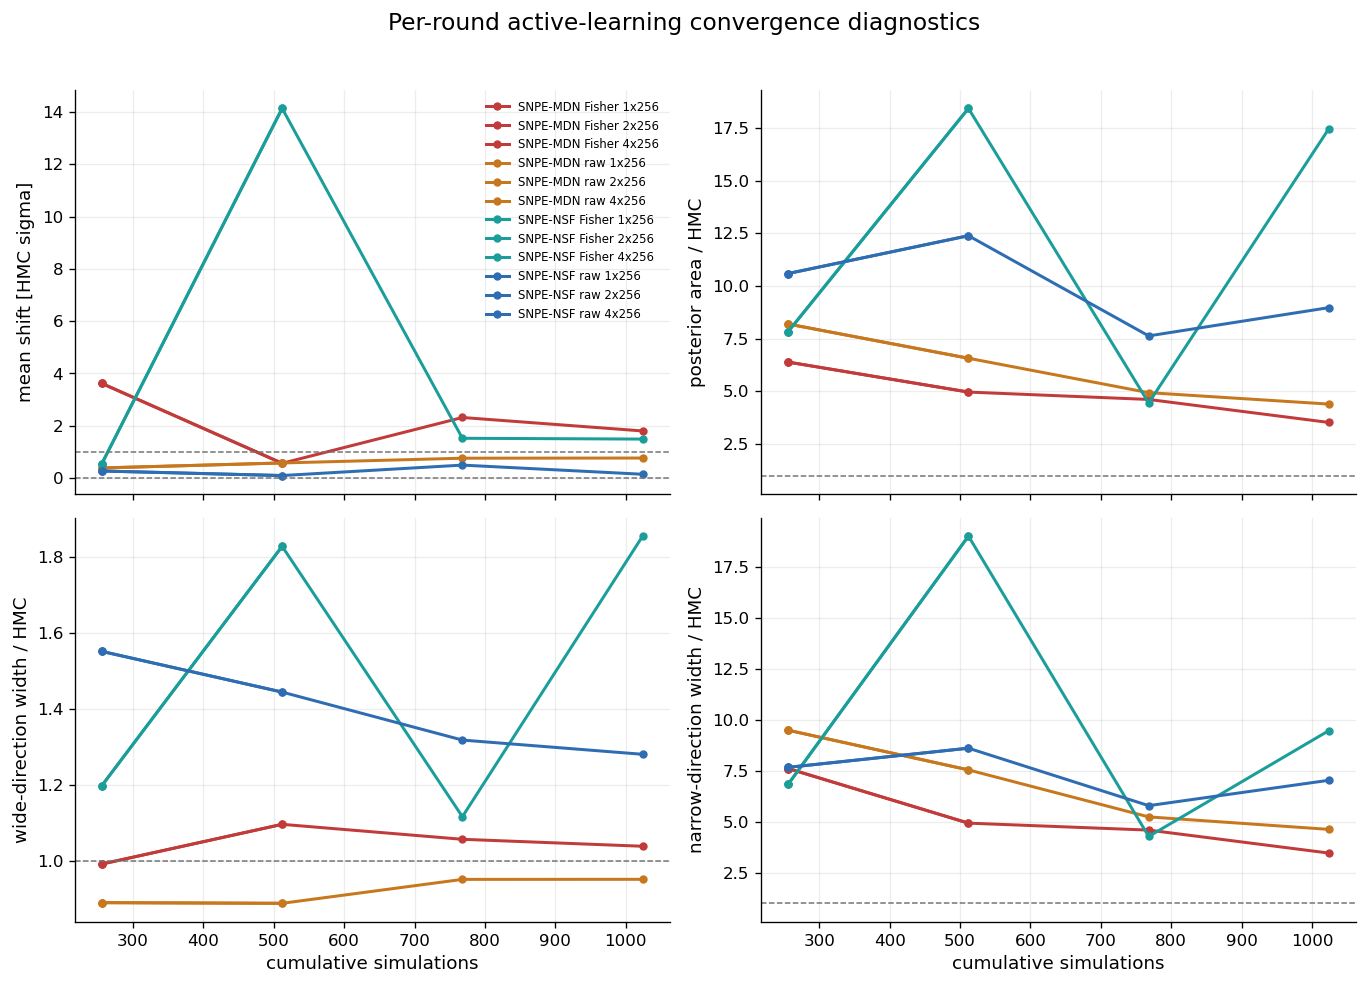

In [33]:
def plot_round_metrics(rows: list[dict[str, Any]]):
    if not rows:
        print("No round metrics available.")
        return
    metrics = [
        ("mean_shift_hmc_sigma", "mean shift [HMC sigma]"),
        ("area_ratio", "posterior area / HMC"),
        ("wide_dir_width_ratio", "wide-direction width / HMC"),
        ("narrow_dir_width_ratio", "narrow-direction width / HMC"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0), sharex=True)
    axes = axes.ravel()
    labels = sorted({row["label"] for row in rows})
    for ax, (metric, ylabel) in zip(axes, metrics):
        for label in labels:
            group = sorted([row for row in rows if row["label"] == label], key=lambda row: row["total_sims"])
            color = "#444444"
            if "NSF raw" in label:
                color = METHOD_COLORS["nsf_raw"]
            elif "NSF Fisher" in label:
                color = METHOD_COLORS["nsf_fisher"]
            elif "MDN raw" in label:
                color = METHOD_COLORS["mdn_raw"]
            elif "MDN Fisher" in label:
                color = METHOD_COLORS["mdn_fisher"]
            ax.plot([row["total_sims"] for row in group], [row[metric] for row in group], marker="o", lw=1.8, ms=4, label=label, color=color)
        ax.axhline(1.0, color="0.45", lw=0.9, ls="--")
        if metric == "mean_shift_hmc_sigma":
            ax.axhline(0.0, color="0.45", lw=0.9, ls="--")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.22)
    for ax in axes[-2:]:
        ax.set_xlabel("cumulative simulations")
    axes[0].legend(fontsize=7, frameon=False)
    fig.suptitle("Per-round active-learning convergence diagnostics", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

plot_round_metrics(round_metric_rows)

## Summary Checklist

Use the final table as the audit trail for this notebook. A run should only be interpreted if it appears as `accepted`, `valid_not_used`, or `accepted_after_run` in the contract table and is present in the posterior metric table. Missing runs are intentionally not substituted with older outputs that do not pass the full contract.

In [34]:
accepted_summary = []
for name, record in accepted_runs.items():
    spec: RunSpec = record["spec"]
    accepted_summary.append({
        "name": name,
        "label": pretty_label(record),
        "kind": spec.kind,
        "total_sims": spec.total_sims if spec.kind != "hmc" else 0,
        "source": str(pathlib.Path(record["dir"]).relative_to(SBI_DIR) if pathlib.Path(record["dir"]).is_relative_to(SBI_DIR) else record["dir"]),
    })

display_table(sorted(accepted_summary, key=lambda row: (row["kind"], row["total_sims"] or 0, row["name"])))

missing = sorted(set(spec.name for spec in RUN_SPECS) - set(accepted_runs))
if missing:
    print("Missing/not accepted runs:")
    for name in missing:
        print(" -", name)
    print("Set RUN_MISSING=True in the configuration cell to generate these into the clean low-budget directory.")
else:
    print("All requested low-budget analytical SBI validation runs are accepted.")

,name,label,kind,total_sims,source
0,student_t_nsim64,Student-t 64 sims,compressed,64,outputs/theory_sbi/analytical_sbi_active_learn...
1,student_t_nsim128,Student-t 128 sims,compressed,128,outputs/theory_sbi/compressed_likelihood_stude...
2,student_t_nsim256,Student-t 256 sims,compressed,256,outputs/theory_sbi/compressed_likelihood_stude...
3,hmc_strict,HMC strict,hmc,0,outputs/theory_sbi/joint_gg_gy_gtau_gkappa_lin...
4,snpe_mdn_fisher_1x256,SNPE-MDN Fisher 1x256,sbi,256,outputs/theory_sbi/analytical_sbi_active_learn...
5,snpe_mdn_raw_1x256,SNPE-MDN raw 1x256,sbi,256,outputs/theory_sbi/analytical_sbi_active_learn...
6,snpe_nsf_fisher_1x256,SNPE-NSF Fisher 1x256,sbi,256,outputs/theory_sbi/analytical_sbi_active_learn...
7,snpe_nsf_raw_1x256,SNPE-NSF raw 1x256,sbi,256,outputs/theory_sbi/analytical_sbi_active_learn...
8,snpe_mdn_fisher_2x256,SNPE-MDN Fisher 2x256,sbi,512,outputs/theory_sbi/analytical_sbi_active_learn...
9,snpe_mdn_raw_2x256,SNPE-MDN raw 2x256,sbi,512,outputs/theory_sbi/analytical_sbi_active_learn...


All requested low-budget analytical SBI validation runs are accepted.
